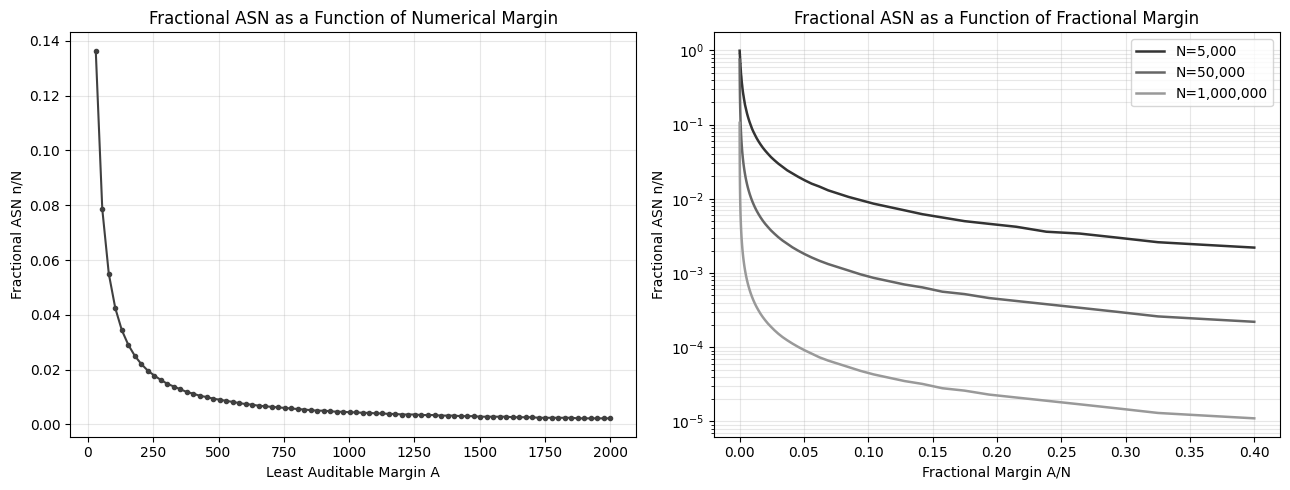

In [1]:
#!/usr/bin/env python3
from __future__ import annotations

import functools
import math
from typing import Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt


# ---------- Normal quantile (Acklam approximation; no SciPy needed) ----------
def norm_ppf(p: float) -> float:
    if p <= 0.0:
        return -math.inf
    if p >= 1.0:
        return math.inf

    a = [-3.969683028665376e+01,
          2.209460984245205e+02,
         -2.759285104469687e+02,
          1.383577518672690e+02,
         -3.066479806614716e+01,
          2.506628277459239e+00]
    b = [-5.447609879822406e+01,
          1.615858368580409e+02,
         -1.556989798598866e+02,
          6.680131188771972e+01,
         -1.328068155288572e+01]
    c = [-7.784894002430293e-03,
         -3.223964580411365e-01,
         -2.400758277161838e+00,
         -2.549732539343734e+00,
          4.374664141464968e+00,
          2.938163982698783e+00]
    d = [ 7.784695709041462e-03,
          3.224671290700398e-01,
          2.445134137142996e+00,
          3.754408661907416e+00]

    plow = 0.02425
    phigh = 1 - plow

    if p < plow:
        q = math.sqrt(-2 * math.log(p))
        return (((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) / \
               ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1)

    if p > phigh:
        q = math.sqrt(-2 * math.log(1 - p))
        return -(((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) / \
                ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1)

    q = p - 0.5
    r = q*q
    return (((((a[0]*r + a[1])*r + a[2])*r + a[3])*r + a[4])*r + a[5]) * q / \
           (((((b[0]*r + b[1])*r + b[2])*r + b[3])*r + b[4])*r + 1)


# ---------- Hypergeometric P(X=0 | K) in log-space ----------
def log_comb(n: int, k: int) -> float:
    if k < 0 or k > n:
        return -math.inf
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)


@functools.lru_cache(maxsize=None)
def Ku_upper_from_zero_successes(N: int, n: int, alpha_K: float) -> int:
    """
    Observed k=0 successes. Return Ku(n) = max K such that P(X=0 | K) >= alpha_K,
    where X ~ Hypergeom(N, K, n).
    """
    if not (0 <= n <= N):
        raise ValueError("Require 0 <= n <= N.")
    if n == 0:
        return N

    log_denom = log_comb(N, n)
    target = math.log(alpha_K)

    lo, hi = 0, N - n
    while lo < hi:
        mid = (lo + hi + 1) // 2
        lp0 = log_comb(N - mid, n) - log_denom
        if lp0 >= target:
            lo = mid
        else:
            hi = mid - 1
    return lo


# ===== Left-panel helpers (margin-scale M = N*x) =====
def halfwidth_and_Ku(
    N: int,
    n: int,
    L: int,
    alpha_e: float,
    alpha_K: float,
) -> Tuple[float, int]:
    Ku = Ku_upper_from_zero_successes(N, n, alpha_K)
    var_pop = (L * Ku) / N
    fpc = (N - n) / (N - 1) if N > 1 else 0.0
    se = math.sqrt(fpc * var_pop / n) if n > 0 else math.inf
    z = norm_ppf(1 - alpha_e / 2)
    return z * se, Ku


def min_n_for_halfwidth_M(
    N: int,
    x: float,
    L: int,
    alpha_e: float,
    alpha_K: float,
    n_lo: int = 1,
) -> int:
    if x <= 0:
        return max(1, n_lo)

    lo, hi = max(1, n_lo), N
    while lo < hi:
        mid = (lo + hi) // 2
        w, _ = halfwidth_and_Ku(N, mid, L, alpha_e, alpha_K)
        if w <= x:
            hi = mid
        else:
            lo = mid + 1
    return lo


def compute_curve_for_N_M(
    N: int,
    margins: np.ndarray,
    L: int,
    alpha_e: float,
    alpha_K: float,
) -> np.ndarray:
    fracs = np.zeros_like(margins, dtype=float)
    order = np.argsort(margins)[::-1]
    n_lo = 1
    for idx in order:
        M = float(margins[idx])
        x = M / N
        n = min_n_for_halfwidth_M(N, x, L, alpha_e, alpha_K, n_lo=n_lo)
        fracs[idx] = n / N
        n_lo = n
    return fracs


# ===== Right-panel helpers (fractional x on x-axis) =====
def halfwidth_x(
    N: int,
    n: int,
    L: int,
    alpha_e: float,
    alpha_K: float,
) -> float:
    Ku = Ku_upper_from_zero_successes(N, n, alpha_K)
    var_pop = (L * Ku) / N
    fpc = (N - n) / (N - 1) if N > 1 else 0.0
    se = math.sqrt(fpc * var_pop / n) if n > 0 else math.inf
    z = norm_ppf(1 - alpha_e / 2)
    return z * se


def min_n_for_halfwidth_x(
    N: int,
    x: float,
    L: int,
    alpha_e: float,
    alpha_K: float,
    n_lo: int = 1,
    n_hi: Optional[int] = None,
) -> int:
    if x <= 0:
        return max(1, n_lo)

    lo = max(1, n_lo)
    hi = N if n_hi is None else min(N, max(lo, n_hi))

    if halfwidth_x(N, hi, L, alpha_e, alpha_K) > x:
        hi = N

    while lo < hi:
        mid = (lo + hi) // 2
        if halfwidth_x(N, mid, L, alpha_e, alpha_K) <= x:
            hi = mid
        else:
            lo = mid + 1
    return lo


# ===================== Plot side-by-side =====================
alpha_e = 0.045
alpha_K = 0.005
L = 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ---- LEFT (adapted first figure): only N=5000, grayscale, no legend ----
N_left = 5_000
margin_min = 30
margin_max = 2000
num_points = 80
margins = np.linspace(margin_min, margin_max, num_points)

fracs_left = compute_curve_for_N_M(N_left, margins, L, alpha_e, alpha_K)
ax1.plot(margins, fracs_left, color="0.25", marker="o", markersize=3, linewidth=1.5)

ax1.set_xlabel("Least Auditable Margin A")
ax1.set_ylabel("Fractional ASN n/N")
ax1.set_title(f"Fractional ASN as a Function of Numerical Margin")
ax1.grid(True, which="both", alpha=0.3)
# (no legend)

# ---- RIGHT (your second figure, same settings/appearance; just drawn on ax2) ----
Ns = [5_000, 50_000, 1_000_000]
# Helpful asymptotic constant for an initial bracket: n ≈ C*sqrt(L)/x
z = norm_ppf(1 - alpha_e)
C = z * math.sqrt(-math.log(alpha_K)) * math.sqrt(L)

# Choose an x-range that spans the *same margin range* 10..2000 across all N:
x_min = 40 / max(Ns)
x_max = 2000 / min(Ns)
num_points = 90
xs = np.logspace(math.log10(x_min), math.log10(x_max), num_points)

# Use grayscale colors instead of the previous colors
grays = [f'0.{i}' for i in range(2, 9, 2)]
for N, c in zip(Ns, grays):
    fracs = np.zeros_like(xs, dtype=float)

    order = np.argsort(xs)[::-1]
    n_lo = 1
    for idx in order:
        x = float(xs[idx])

        n_guess = int(math.ceil(C / x))
        n_hi = min(N, max(n_lo, 2 * n_guess))

        n = min_n_for_halfwidth_x(N, x, L, alpha_e, alpha_K, n_lo=n_lo, n_hi=n_hi)
        fracs[idx] = n / N
        n_lo = n

    ax2.plot(xs, fracs, color=c, linewidth=1.8, label=f"N={N:,}")

ax2.set_yscale("log")
# ax2.set_xscale("log")
ax2.set_xlabel("Fractional Margin A/N")
ax2.set_ylabel("Fractional ASN n/N")
ax2.set_title("Fractional ASN as a Function of Fractional Margin")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()
